In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

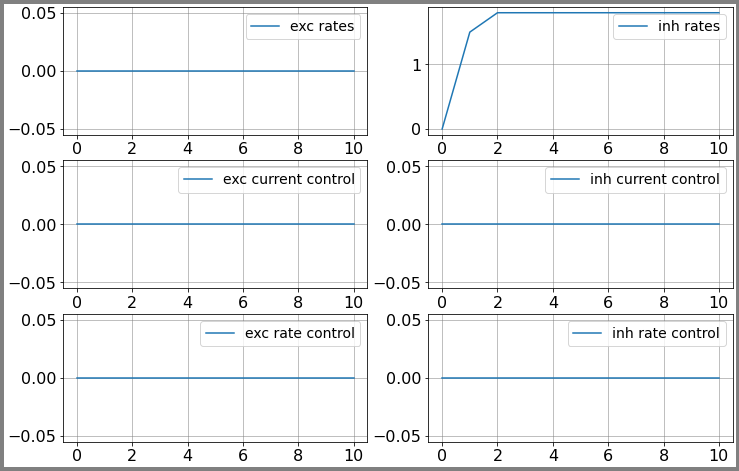

In [230]:
aln = RateModel()

aln.params.dt = 1.
aln.params['duration'] = 10.
control0 = aln.getZeroControl()
target = aln.getZeroTarget()
#control0 = step_control(maxI_ = 1.)

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.ext_exc_current = 0.

aln.params.c_gl =0.1*aln.params.c_gl

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroFullState()
plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

for i in range(len(state_vars)):
    state[:,i,:] = aln.state[state_vars[i]]

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]
        
high_state_vars[5] = 0.
high_state_vars[0] = 0.

In [8]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                    

In [9]:
tol = 1e-18

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

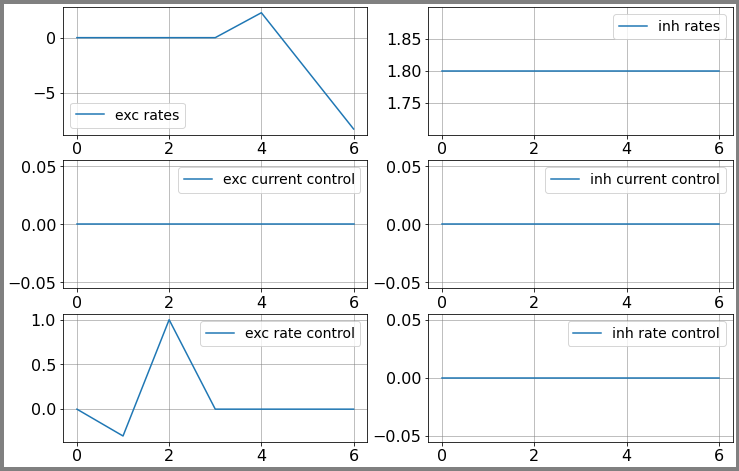

[[ 0.          0.          0.92592593 -2.16049383 -2.16049383 -2.16049383
  -2.16049383]]


In [231]:
dur = 6.
dur_pre = 0.
dur_post = 0.
aln.params.duration = dur

control_ind = 2
control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = - 0.1
control0[0,control_ind,1] = -0.3
control0[0,control_ind,2] = 1.
#control0[0,control_ind,3] = 2.
setinitvars(high_state_vars)

plotFunc.plot_traces(aln, control0)

print(aln.state["seem"])
# [[0.8863383  0.92141907 0.8817336  0.88375921 0.88493324]]

target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,:]
target[0,1,:] = aln.rates_inh[0,:]

In [233]:
cost.setParams(1., 1.0, 1.* 1e0)
max_cntrl = 100. * 5.

setinitvars(high_state_vars)
max_it = 500
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,:]
#control2[:,2,2] = - 0.3
#control2 = bestControlA_A2[:,:,:]

# "HS", "FR", "PR", "HZ"
cgv = "HS"

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = [control_ind], prec_variables_ = [0,1])

print("grad c= ", grad[0,control_ind,:])

print("best control = ", bestControlA[0,control_ind,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 0.   -0.02 -0.01  0. 

set cost params
RUN  0 , total integrated cost =  1.3528516445741492
RUN  1 , total integrated cost =  1.3528516445741352
RUN  2 , total integrated cost =  1.3528516445741199
RUN  3 , total integrated cost =  1.352851644574105
RUN  4 , total integrated cost =  1.3528516445740908
RUN  5 , total integrated cost =  1.352851644574077
RUN  6 , total integrated cost =  1.3528516445740628
RUN  7 , total integrated cost =  1.3528516445740493
RUN  8 , total integrated cost =  1.3528516445740344
RUN  9 , total integrated cost =  1.3528516445740193
RUN  10 , total integrated cost =  1.3528516445740049
RUN  11 , total integrated cost =  1.3528516445739913
RUN  12 , total integrated cost =  1.3528516445739784
RUN  13 , total integrated cost =  1.3528516445739642
RUN  14 , total integrated cost =  1.3528516445739487
RUN  15 , total integrated cost =  1.3528516445739356
RUN  16 , total integrated cost =  1.352851644573922
RUN  17 , total integrated cost =  1.3528516445739078
RUN  18 , total integrate

RUN  163 , total integrated cost =  1.3528516445728265
RUN  164 , total integrated cost =  1.3528516445728203
RUN  165 , total integrated cost =  1.3528516445728136
RUN  166 , total integrated cost =  1.3528516445728058
RUN  167 , total integrated cost =  1.3528516445727987
RUN  168 , total integrated cost =  1.3528516445727923
RUN  169 , total integrated cost =  1.3528516445727845
RUN  170 , total integrated cost =  1.3528516445725816
RUN  171 , total integrated cost =  1.3528516445725804
RUN  172 , total integrated cost =  1.3528516445725802
RUN  173 , total integrated cost =  1.35285164457258
RUN  174 , total integrated cost =  1.35285164457258
Control only changes marginally.
Improved over  174  iterations by  1.1598899618547875e-10  percent.
grad c=  [1.85514154e-07 1.40775542e-07 4.92139465e-08 4.97356347e-08
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
best control =  [-0.04185521 -0.1513277   0.80502314  0.10714985  0.          0.
  0.        ]
total runtime =  0.0


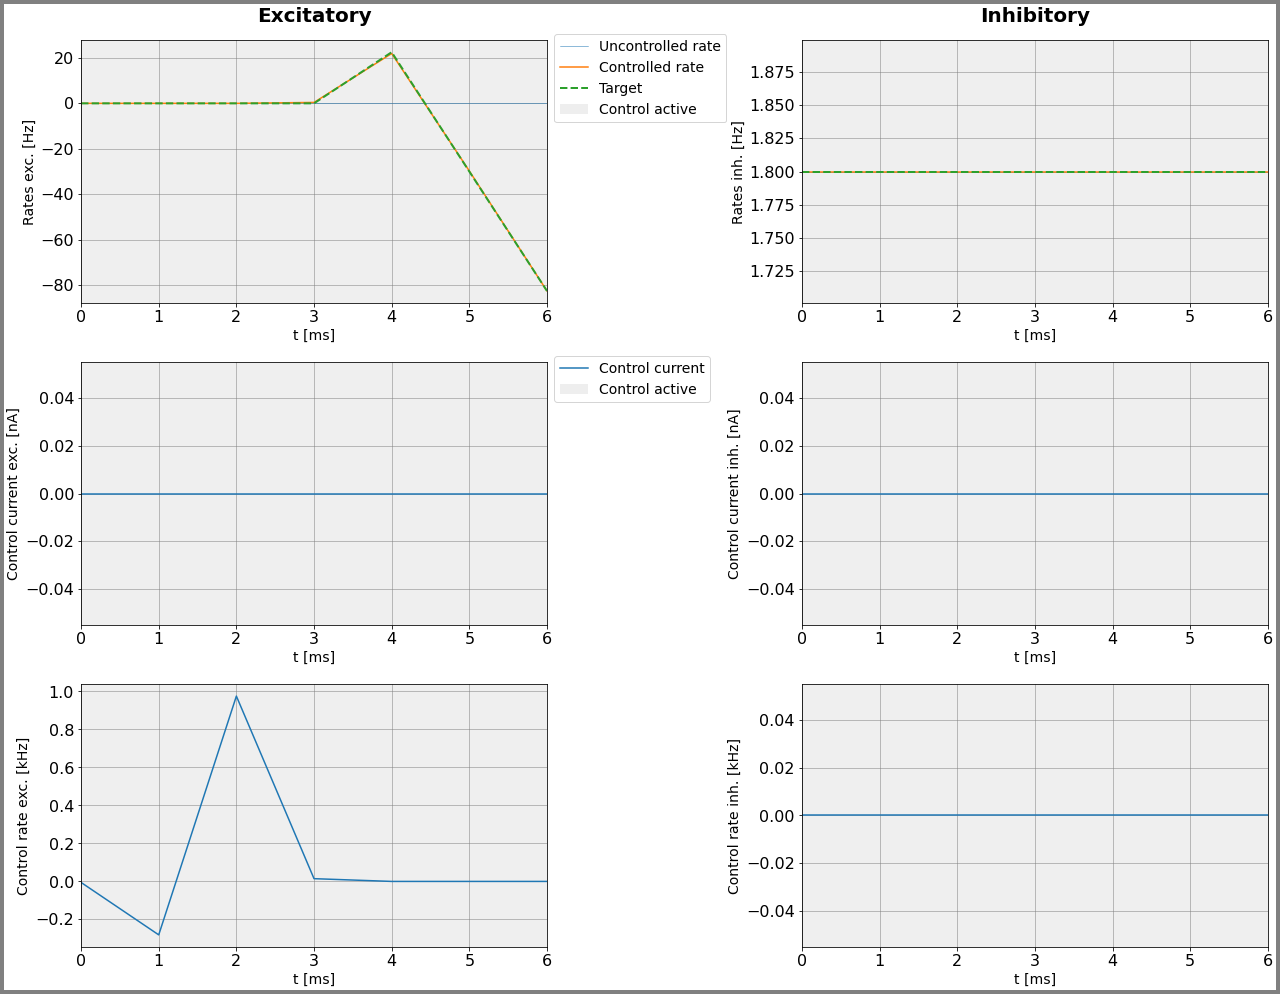

In [224]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

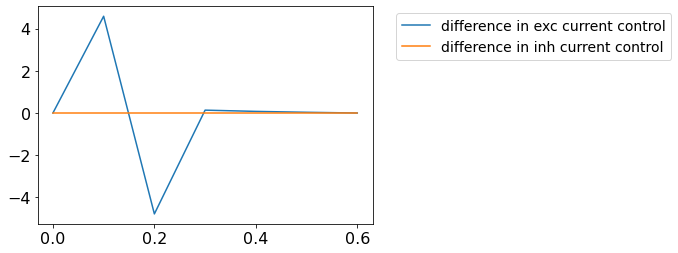

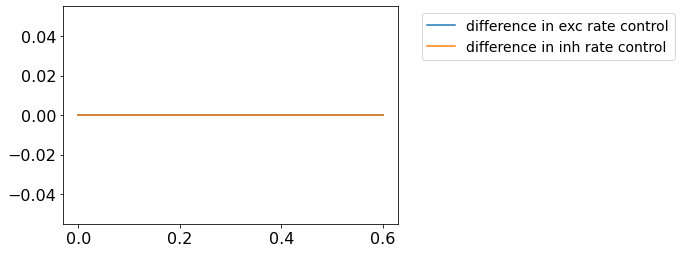

In [752]:
diff = control0 - bestControlA
#diff[0,2,-2:] = 0.

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [225]:
setinitvars(high_state_vars)
max_it = 100
start_step = 10.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-8

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA_A2[:,:,:]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control4, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, control_variables_ = [control_ind])

RUN  0 , total integrated cost:  22118.11185030309
RUN  1 , total integrated cost:  980.852826488114
RUN  2 , total integrated cost:  931.8059313272761
RUN  3 , total integrated cost:  900.5758848691275
RUN  4 , total integrated cost:  875.7206368705613
RUN  5 , total integrated cost:  850.2101836791171
RUN  6 , total integrated cost:  824.9129965872031
RUN  7 , total integrated cost:  799.2392908558027
RUN  8 , total integrated cost:  773.2187285727224
RUN  9 , total integrated cost:  746.5792818780488
RUN  10 , total integrated cost:  721.9174735992277
RUN  11 , total integrated cost:  697.6795912380986
RUN  12 , total integrated cost:  673.8825653891809
RUN  13 , total integrated cost:  650.5266321538305
RUN  14 , total integrated cost:  627.6120355634168
RUN  15 , total integrated cost:  605.1390268792597
RUN  16 , total integrated cost:  583.1266719877813
RUN  17 , total integrated cost:  562.671418876488
RUN  18 , total integrated cost:  542.5900772627257
RUN  19 , total integrat

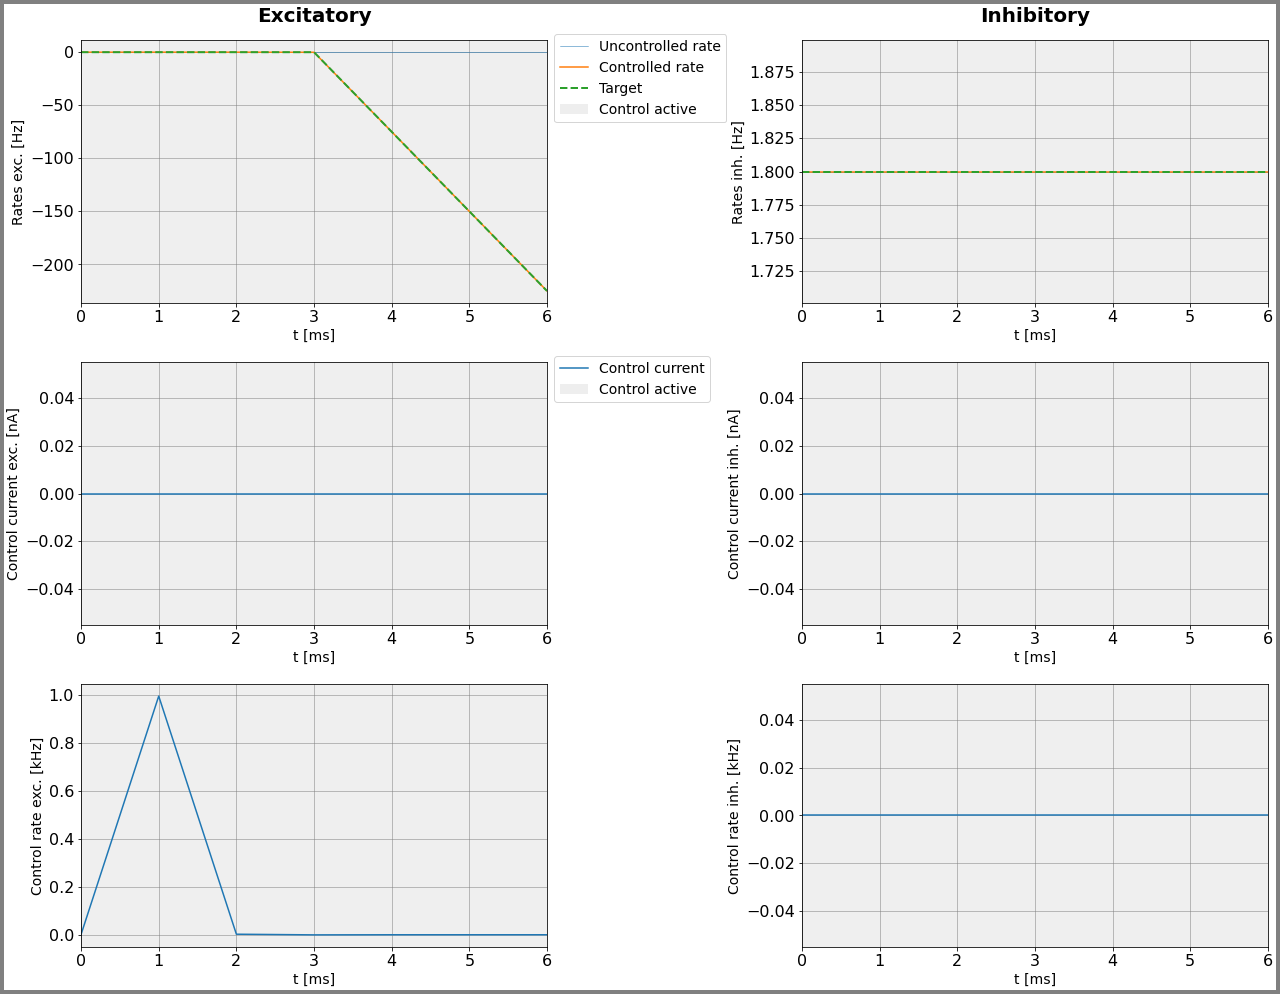

In [206]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

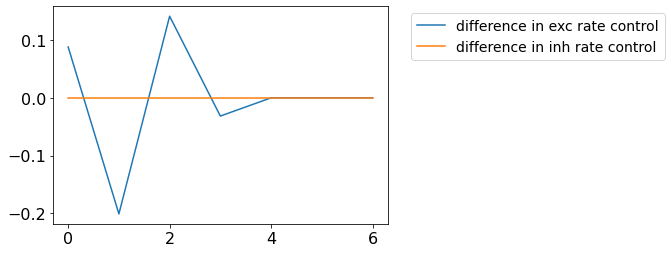

In [227]:
diff = control0 - bestControlA_A2
diff[0,2,-2:] = 0.

t = np.arange(0,dur+aln.params.dt, aln.params.dt)

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

-0.0004884455958080736


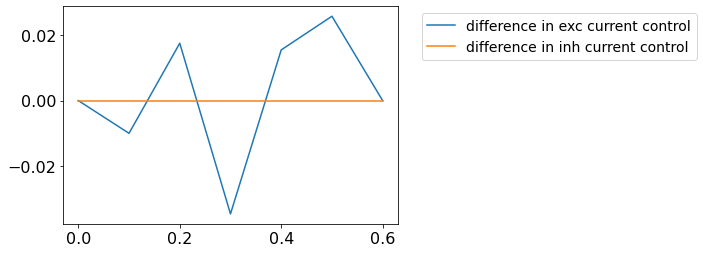

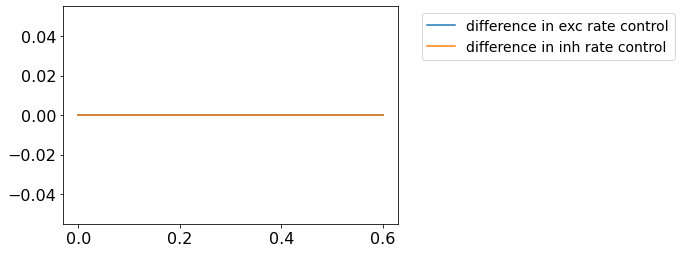

In [29]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

c_diff = costA_A2[6] - costA[3]
print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()